# 【課題】糖尿病の進行状況を予測（回帰）しよう

## データを読み込む

まずは、最初のセルを実行し、データを読み込んでください。今回はscikit-learnに標準で入っているデータを使います。

In [1]:
# scikit-learnの糖尿病のデータセットを読み込む（変更しないでください）
from sklearn import datasets
diabetes_data = datasets.load_diabetes()

読み込んだデータについて確認します。

In [2]:
# データセットのDESCRを確認する（変更しないでください）
print(diabetes_data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
# 読み込んだデータが何行何列かをshapeで確認する（変更しないでください）
print(diabetes_data.data.shape)
print(diabetes_data.target.shape)

(442, 10)
(442,)


In [5]:
# スライスして X と y を作成する（変更しないでください）
X = diabetes_data.data[:, 2:4]
y = diabetes_data.target

`X` の最初の10件を表示して、データがどのようになっているかを確認します。

In [6]:
# 特徴量（説明変数）の最初の10件をスライスして表示する
# （以下にコードを書いてください）
from sklearn import datasets

# 糖尿病データセット読み込み
diabetes_data = datasets.load_diabetes()

# BMIと平均血圧の特徴量だけ抽出
X = diabetes_data.data[:, 2:4]

# 特徴量（説明変数）の最初の10件を表示
print(X[:10])



[[ 0.06169621  0.02187239]
 [-0.05147406 -0.02632753]
 [ 0.04445121 -0.00567042]
 [-0.01159501 -0.03665608]
 [-0.03638469  0.02187239]
 [-0.04069594 -0.01944183]
 [-0.04716281 -0.01599898]
 [-0.00189471  0.06662945]
 [ 0.06169621 -0.04009893]
 [ 0.03906215 -0.03321323]]


このデータは最初から正規化されているため、このような数値となっています。

`y` のデータも表示してみましょう。

In [7]:
# 目的変数の最初の10件をスライスして表示する
# （以下にコードを書いてください）
from sklearn import datasets

# 糖尿病データセット読み込み
diabetes_data = datasets.load_diabetes()

# 目的変数（病気進行度）
y = diabetes_data.target

# 最初の10件を表示
print(y[:10])


[151.  75. 141. 206. 135.  97. 138.  63. 110. 310.]


`y`（糖尿病の進行状況）の数値がどのように計測、あるいは計算されたものかについての説明は公表されていませんが、数値が大きいほど、糖尿病が進行しているものと認識してください。

## データの前処理について

今回は、とくに何か前処理を行なう必要はありませんので、スキップして進めます。

## データを訓練データとテストデータに分ける

X および y を訓練データとテストデータに分けましょう。その際、訓練データ8割、テストデータ2割としてください。また、並び順がランダムになるよう、分割してください。

In [10]:
# 訓練データ8割、テストデータ2割に分割する
# （以下にコードを書いてください）
from sklearn import datasets
from sklearn.model_selection import train_test_split

# データ読み込み
diabetes_data = datasets.load_diabetes()

# 特徴量（BMIと平均血圧）
X = diabetes_data.data[:, 2:4]
# 目的変数（病気進行度）
y = diabetes_data.target

# 訓練8割・テスト2割に分割（ランダム）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=None
)

# 確認用
print("訓練データ X_train の形:", X_train.shape)
print("テストデータ X_test の形:", X_test.shape)
print("訓練データ y_train の形:", y_train.shape)
print("テストデータ y_test の形:", y_test.shape)


訓練データ X_train の形: (353, 2)
テストデータ X_test の形: (89, 2)
訓練データ y_train の形: (353,)
テストデータ y_test の形: (89,)


## モデルを作成して訓練する

ここでは、レッスン本文でも利用した「線形回帰モデル」（`LinearRegression`）を使います。また、作成したモデルに訓練データを渡して、学習を行ないます。

In [12]:
# LinearRegressionの線形回帰モデルを作成する
# （以下にコードを書いてください）
from sklearn.linear_model import LinearRegression
from sklearn import datasets
from sklearn.model_selection import train_test_split

# データ読み込み
diabetes_data = datasets.load_diabetes()
X = diabetes_data.data[:, 2:4]
y = diabetes_data.target

# データ分割（訓練80%、テスト20%）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=None
)

# 線形回帰モデル作成・学習
model = LinearRegression()
model.fit(X_train, y_train)

# 学習済みモデルで予測
y_pred = model.predict(X_test)

# 学習結果の係数と切片を表示
print("係数:", model.coef_)
print("切片:", model.intercept_)


# 訓練データを使って訓練を行なう
# （以下にコードを書いてください）
# 線形回帰モデル作成
model = LinearRegression()

# 訓練データで学習（訓練）
model.fit(X_train, y_train)


係数: [753.21415787 428.01374861]
切片: 150.06065648580497


LinearRegression()

## 期待する性能が出たかを評価する

予測を実行しましょう。

In [13]:
# テストデータを使って予測（回帰）を実行する
# （以下にコードを書いてください）
# テストデータを使って予測する
y_pred = model.predict(X_test)

# 予測結果を表示（最初の10件だけ）
print(y_pred[:10])


[122.6890637  119.2932933  129.54687822 174.74339037 138.17681652
 256.73754504 162.38303878 180.78779966 120.4667627  132.40552219]


モデルの評価を行なううえで、まずは予測値と正解値の散布図を作ります。

c:\Users\chant_s2mci8i\Downloads\pythondev\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chant_s2mci8i\Downloads\pythondev\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chant_s2mci8i\Downloads\pythondev\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20516 (\N{CJK UNIFIED IDEOGRAPH-5024}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chant_s2mci8i\Downloads\pythondev\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chant_s2mci8i\Downloads\pythondev\.venv\Lib\site-packages\I

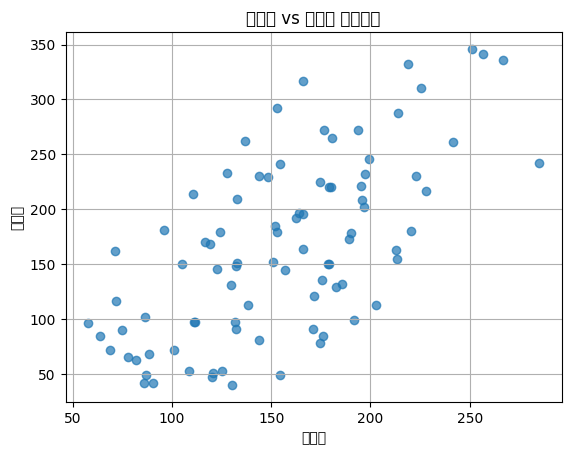

In [14]:
# 横軸が予測値、縦軸は正解値でプロットした散布図を表示する
# （以下にコードを書いてください）
import matplotlib.pyplot as plt

# 散布図の作成
plt.scatter(y_pred, y_test, alpha=0.7)
plt.xlabel("予測値")
plt.ylabel("正解値")
plt.title("予測値 vs 正解値 の散布図")
plt.grid(True)
plt.show()


正解値と予測値の平均二乗誤差を求めます。

In [15]:
# 正解値と予測値の平均二乗誤差を計算して表示する
# （以下にコードを書いてください）
from sklearn.metrics import mean_squared_error

# 平均二乗誤差を計算
mse = mean_squared_error(y_test, y_pred)

# 表示
print(f"平均二乗誤差（MSE）: {mse:.3f}")


平均二乗誤差（MSE）: 3786.222


平均二乗誤差の平方根を計算し、正解値と予測値のズレの大きさを求めましょう。

In [16]:
# 平均二乗誤差の平方根を計算して表示する
# （以下にコードを書いてください）
from sklearn.metrics import mean_squared_error
import numpy as np

# MSEを計算
mse = mean_squared_error(y_test, y_pred)

# RMSEを計算（MSEの平方根）
rmse = np.sqrt(mse)

# 表示
print(f"RMSE（平均二乗誤差の平方根）: {rmse:.3f}")


RMSE（平均二乗誤差の平方根）: 61.532
